In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
no_yellow_viridis = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap('viridis', 256)(np.linspace(0,0.85,256)))

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_116948\4119890076.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  no_yellow_viridis = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap('viridis', 256)(np.linspace(0,0.85,256)))


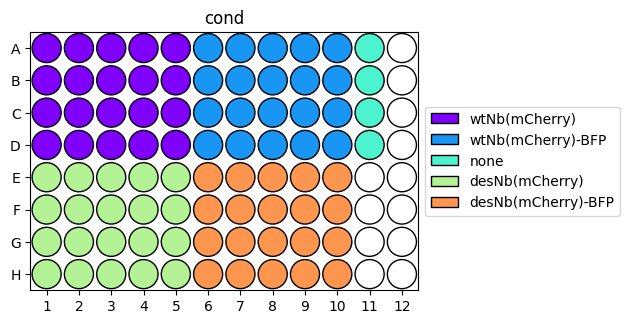

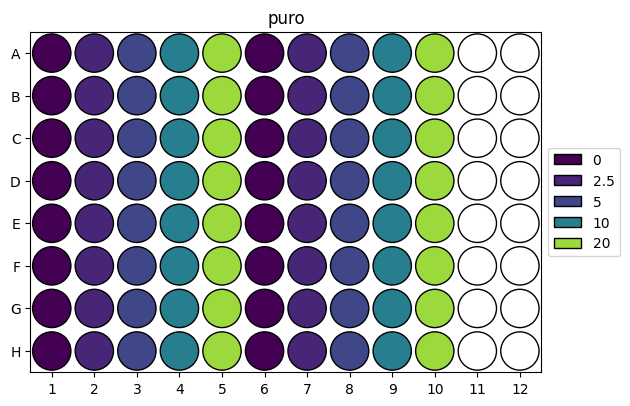

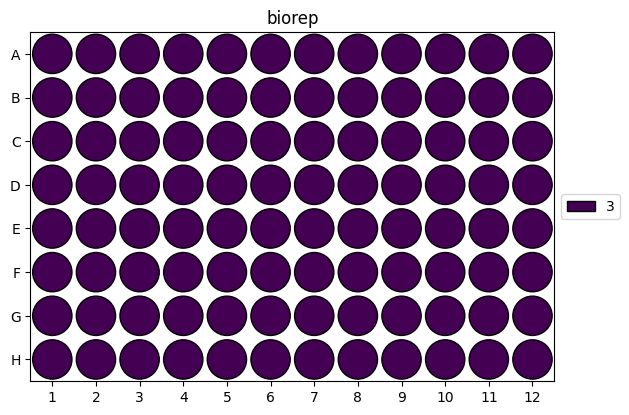

In [4]:
yaml_path_1 = rd.datadir/'data'/'attune'/'Mary'/'2026.07.10_exp66'/'Plate1'/'Single_cell_csvs'/'wells.yaml'
yaml_path_2 = rd.datadir/'data'/'attune'/'Mary'/'2026.07.10_exp66'/'Plate2'/'Single_cell_csvs'/'wells.yaml'
yaml_path_3 = rd.datadir/'data'/'attune'/'Mary'/'2026.07.10_exp66'/'Plate3'/'Single_cell_csvs'/'wells.yaml'
rd.plot.plot_well_metadata(yaml_path_3)

In [5]:
data_path_1 = rd.datadir/'data'/'attune'/'Mary'/'2026.07.10_exp66'/'Plate1'/'Single_cell_csvs'
data_path_2 = rd.datadir/'data'/'attune'/'Mary'/'2026.07.10_exp66'/'Plate2'/'Single_cell_csvs'
data_path_3 = rd.datadir/'data'/'attune'/'Mary'/'2026.07.10_exp66'/'Plate3'/'Single_cell_csvs'

In [6]:
df_1 = rd.flow.load_csv_with_metadata(data_path_1, yaml_path_1)
df_2 = rd.flow.load_csv_with_metadata(data_path_2, yaml_path_2)

In [7]:
df_3 = rd.flow.load_csv_with_metadata(data_path_3, yaml_path_3)

In [8]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

In [9]:
df.rename(columns={'mRuby2-A': 'mCherry-A'})

,cond,puro,biorep,well,population,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,...,TagBFP-A,TagBFP-H,TagBFP-W,Janelia590-A,Janelia590-H,Janelia590-W,mCherry-A,mRuby2-H,mRuby2-W,Time
0,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,525791,308521,144,297030,204176,...,10148.0,5505,68,165,134,0,13,83,0,0.000000
1,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,493300,283200,148,302779,194891,...,21341.0,12211,77,205,181,0,68,105,0,0.000000
2,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,414794,239798,124,302614,200764,...,100234.0,71327,116,205,210,0,228,144,0,0.002042
3,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,256660,182905,121,444736,272314,...,51943.0,44058,110,294,245,0,181,165,0,0.002042
4,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,424941,262006,131,250600,167309,...,19866.0,13526,66,13,56,0,15,94,0,0.002042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13530016,desNb(mCherry)-BFP,10,3,H9,Single Cells,364530,244186,133,148677,115767,...,346.0,241,0,114,127,0,6,68,0,20.996100
13530017,desNb(mCherry)-BFP,10,3,H9,Single Cells,281703,180492,113,210739,148330,...,1428.0,1015,5,115,111,0,247,112,0,20.997000
13530018,desNb(mCherry)-BFP,10,3,H9,Single Cells,379908,249779,117,239634,174268,...,313.0,188,0,168,174,0,163,145,0,20.998000
13530019,desNb(mCherry)-BFP,10,3,H9,Single Cells,316612,188700,124,246508,169251,...,3420.0,2375,37,183,174,0,196,90,0,20.999000


In [10]:
df

,cond,puro,biorep,well,population,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,...,TagBFP-A,TagBFP-H,TagBFP-W,Janelia590-A,Janelia590-H,Janelia590-W,mRuby2-A,mRuby2-H,mRuby2-W,Time
0,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,525791,308521,144,297030,204176,...,10148.0,5505,68,165,134,0,13,83,0,0.000000
1,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,493300,283200,148,302779,194891,...,21341.0,12211,77,205,181,0,68,105,0,0.000000
2,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,414794,239798,124,302614,200764,...,100234.0,71327,116,205,210,0,228,144,0,0.002042
3,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,256660,182905,121,444736,272314,...,51943.0,44058,110,294,245,0,181,165,0,0.002042
4,wtNb(mCherry)-BFP,20.0,1,A10,Single Cells,424941,262006,131,250600,167309,...,19866.0,13526,66,13,56,0,15,94,0,0.002042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13530016,desNb(mCherry)-BFP,10,3,H9,Single Cells,364530,244186,133,148677,115767,...,346.0,241,0,114,127,0,6,68,0,20.996100
13530017,desNb(mCherry)-BFP,10,3,H9,Single Cells,281703,180492,113,210739,148330,...,1428.0,1015,5,115,111,0,247,112,0,20.997000
13530018,desNb(mCherry)-BFP,10,3,H9,Single Cells,379908,249779,117,239634,174268,...,313.0,188,0,168,174,0,163,145,0,20.998000
13530019,desNb(mCherry)-BFP,10,3,H9,Single Cells,316612,188700,124,246508,169251,...,3420.0,2375,37,183,174,0,196,90,0,20.999000


In [11]:
df_fractions=df
df_fractions.loc[df_fractions['TagBFP-A'] <=0, 'TagBFP-A'] = 1
df_fractions.loc[df_fractions['TagBFP-H'] <=0, 'TagBFP-H'] = 1
df_fractions.loc[df_fractions['mRuby2-A'] <=0, 'mRuby2-A'] = 1
df_fractions.loc[df_fractions['mRuby2-H'] <=0, 'mRuby2-H'] = 1
df_fractions.loc[df_fractions['iRFP670-A'] <=0, 'iRFP670-A'] = 1
df_fractions.loc[df_fractions['iRFP670-H'] <=0, 'iRFP670-H'] = 1


In [12]:
channel_list = [ 'TagBFP-A', 'mRuby2-A', 'iRFP670-A' ]
for c in channel_list:
    df = df[df[c] > 0]

In [13]:
numSamples = 10**4
small_data_all = df.groupby(['cond']).sample(n=numSamples, random_state=1)

In [14]:
df_no_bfp = df[df['cond'] == 'none']
bfp_threshold_hard = df_no_bfp['TagBFP-A'].quantile(0.99)
mruby_threshold = 2500

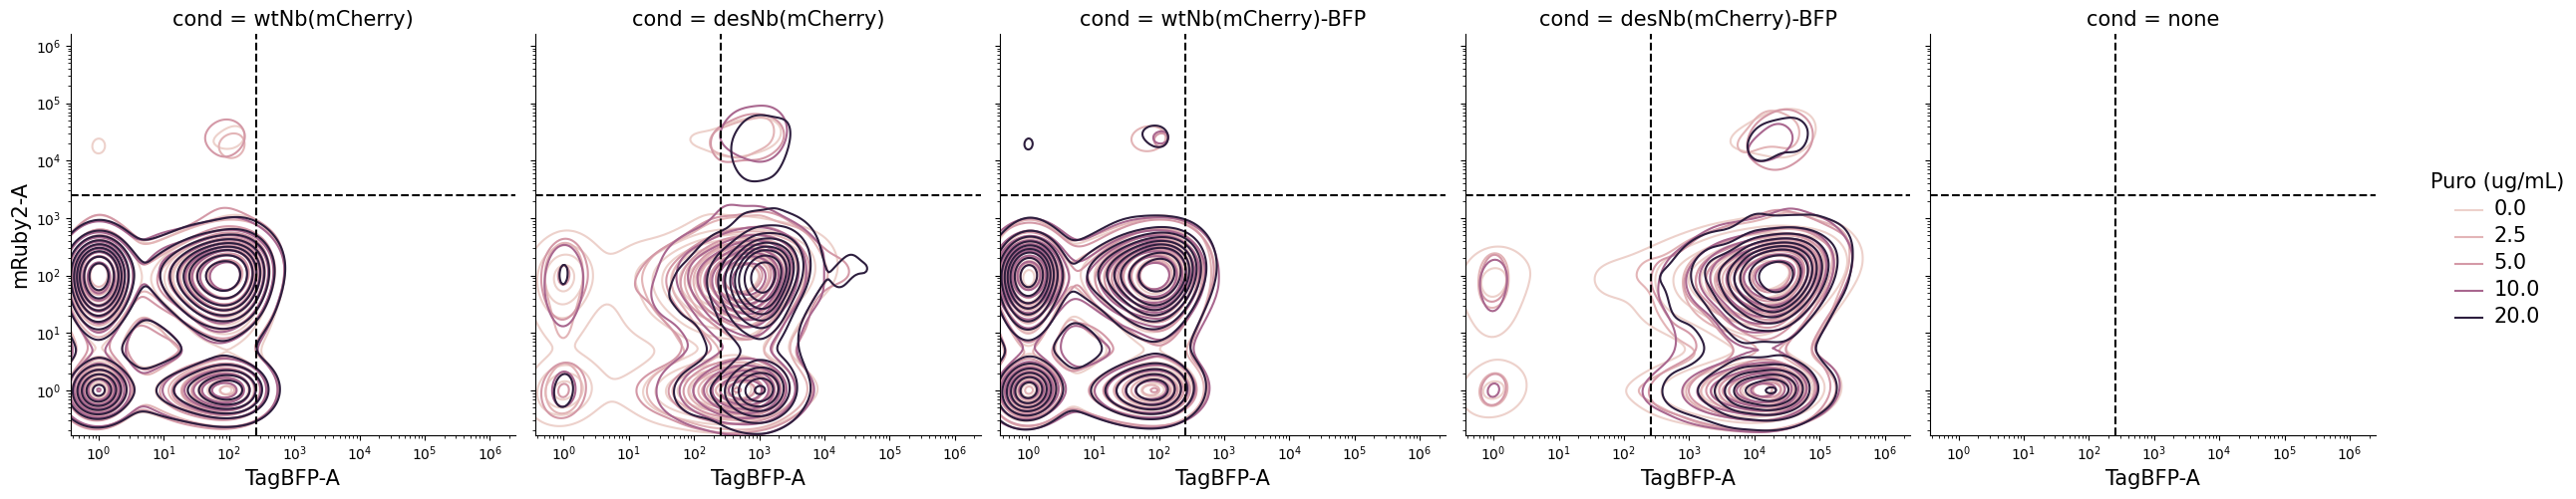

In [15]:
cond_order = ['wtNb(mCherry)', 'desNb(mCherry)', 'wtNb(mCherry)-BFP', 'desNb(mCherry)-BFP', 'none']
small_data_all['cond'] = pd.Categorical(
    small_data_all['cond'], 
    categories=cond_order, 
    ordered=True
)

g = sns.displot(data = small_data_all, x = 'TagBFP-A', y = 'mRuby2-A', hue = 'puro',col = 'cond', log_scale=True, common_norm=False, kind='kde', facet_kws=dict(margin_titles=True))
ax_vlines = [ax.axvline(bfp_threshold_hard, color='black', linestyle='--') for ax in g.axes.flatten()]
ax_hlines = [ax.axhline(mruby_threshold, color='black', linestyle='--') for ax in g.axes.flatten()]
ax_xfontsizes = [ax.set_xlabel(ax.get_xlabel(), fontsize=15) for ax in g.axes.flatten()]
ax_yfontsizes = [ax.set_ylabel(ax.get_ylabel(), fontsize=15) for ax in g.axes.flatten()]
ax_titles = [ax.set_title(ax.get_title(), fontsize=15) for ax in g.axes.flatten()]
ax_row_titles = [ax.set_title(ax.get_title(), fontsize=15) for ax in g.axes[:,0]]

# Change the legend title
g.legend.set_title("Puro (ug/mL)")

# Change font sizes
plt.setp(g.legend.get_texts(), fontsize=15)
g.legend.get_title().set_fontsize(15)


In [16]:
summary_dfs = []
groupby_cols = ['cond', 'puro', 'biorep', 'well']
sc_count = df_fractions.groupby(groupby_cols).size().reset_index(name = "sc_count")
mruby_count = df_fractions.groupby(groupby_cols).apply(lambda df: sum(df['mRuby2-A'] > mruby_threshold)).reset_index(name = "mruby_count")
bfp_count = df_fractions.groupby(groupby_cols).apply(lambda df: sum(df['TagBFP-A'] >bfp_threshold_hard)).reset_index(name = "bfp_count")



dfiii = sc_count.merge(mruby_count)
dfi = dfiii.merge(bfp_count)
dfi["purity"] = dfi['mruby_count'] / dfi['sc_count']*100
summary_dfs.append(dfi)

summary_df = pd.concat(summary_dfs, ignore_index=True)

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_116948\4147923616.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


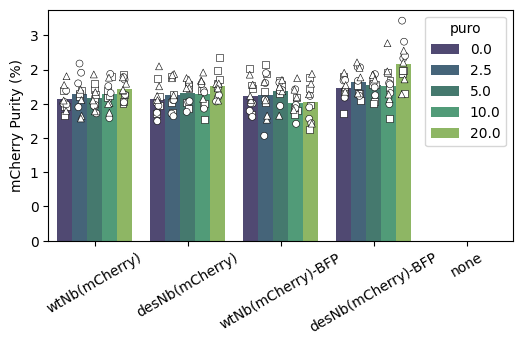

In [17]:
palette = ['#4B4279', '#3C6682',"#3C8273" ,  '#45A778', '#8FC456',]
hue = 'puro'
hue_order = [0, 2.5, 5, 10, 20]
# General plotting params
x = 'cond'
y = 'purity'
order = ['wtNb(mCherry)', 'desNb(mCherry)', 'wtNb(mCherry)-BFP', 'desNb(mCherry)-BFP', 'none']


# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

markers={1: 's', 2: 'o', 3: '^'}
# Plot
sns.barplot(
    ax=ax, data=summary_df,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df[summary_df['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )

# sns.stripplot(
#     ax=ax, data=data_iMN_count_reps,
#     x=x, y=y,
#     order=order, hue=hue,
#     dodge=True, marker='o',
#     palette={puro:'white' for puro in hue_order}, size=5,
#     edgecolor='black', linewidth=0.4,legend = False)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('mCherry Purity (%)')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '2.5': '2.5 µg/mL', '5': '5 µg/mL', '10': '10 µg/mL', '20': '20 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
# new_labels = [lmap[str(label)] for label in unique.keys()]

# ax.legend(
#     unique.values(),
#     new_labels,
#     title='Puro conc.',
#     loc='upper left',
#     bbox_to_anchor=(1,1),
#     frameon=False
# )

ax.tick_params(axis='x', labelrotation=30)

# Format
#plt.suptitle('Homer1 MOI 1')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_116948\727077942.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


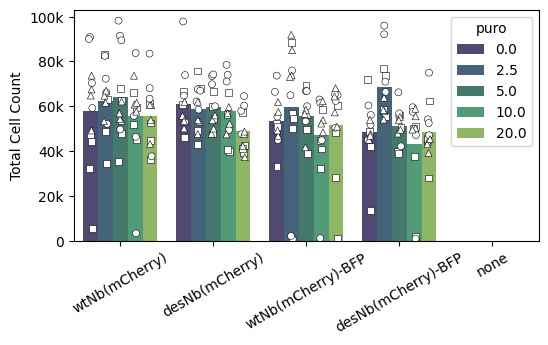

In [18]:
palette = ['#4B4279', '#3C6682',"#3C8273" ,  '#45A778', '#8FC456',]
hue = 'puro'
hue_order = [0, 2.5, 5, 10, 20]
# General plotting params
x = 'cond'
y = 'sc_count'
order = ['wtNb(mCherry)', 'desNb(mCherry)', 'wtNb(mCherry)-BFP', 'desNb(mCherry)-BFP', 'none']


# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

markers={1: 's', 2: 'o', 3: '^'}
# Plot
sns.barplot(
    ax=ax, data=summary_df,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df[summary_df['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )

# sns.stripplot(
#     ax=ax, data=data_iMN_count_reps,
#     x=x, y=y,
#     order=order, hue=hue,
#     dodge=True, marker='o',
#     palette={puro:'white' for puro in hue_order}, size=5,
#     edgecolor='black', linewidth=0.4,legend = False)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('Total Cell Count')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '2.5': '2.5 µg/mL', '5': '5 µg/mL', '10': '10 µg/mL', '20': '20 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
# new_labels = [lmap[str(label)] for label in unique.keys()]

# ax.legend(
#     unique.values(),
#     new_labels,
#     title='Puro conc.',
#     loc='upper left',
#     bbox_to_anchor=(1,1),
#     frameon=False
# )

ax.tick_params(axis='x', labelrotation=30)

# Format
#plt.suptitle('Homer1 MOI 1')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')